# Ejercicio 10: Re-ranking

**Objetivo:** Implementar y evaluar un pipeline de Recuperación de Información en dos etapas, y analizar el impacto del re-ranking en la calidad del ranking.

## Parte 1. Preparación del corpus

* Cargar el corpus (documentos/pasajes).
* Cargar las consultas (queries).
* Cargar qrels (relevancia).

In [2]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import pandas as pd

C:\Users\luis3\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\beir\util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
DATASET_NAME = "scifact"
DATA_DIR = "../data/beir_datasets"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{DATASET_NAME}.zip"
util.download_and_unzip(url, DATA_DIR)

'../data/beir_datasets\\scifact'

In [5]:
dataset_path = DATA_DIR + "/" + DATASET_NAME
corpus, queries, qrels = GenericDataLoader(dataset_path).load(split="test")

  0%|          | 0/5183 [00:00<?, ?it/s]

In [6]:
df_corpus = (
    pd.DataFrame.from_dict(corpus, orient="index")
      .reset_index()
      .rename(columns={"index": "doc_id"})
)

df_corpus

,doc_id,text,title
0,4983,Alterations of the architecture of cerebral wh...,Microstructural development of human newborn c...
1,5836,Myelodysplastic syndromes (MDS) are age-depend...,Induction of myelodysplasia by myeloid-derived...
2,7912,ID elements are short interspersed elements (S...,"BC1 RNA, the transcript from a master gene for..."
3,18670,DNA methylation plays an important role in bio...,The DNA Methylome of Human Peripheral Blood Mo...
4,19238,Two human Golli (for gene expressed in the oli...,The human myelin basic protein gene is include...
...,...,...,...
5178,195689316,BACKGROUND The main associations of body-mass ...,Body-mass index and cause-specific mortality i...
5179,195689757,A key aberrant biological difference between t...,Targeting metabolic remodeling in glioblastoma...
5180,196664003,A signaling pathway transmits information from...,Signaling architectures that transmit unidirec...
5181,198133135,AIMS Trabecular bone score (TBS) is a surrogat...,"Association between pre-diabetes, type 2 diabe..."


In [7]:
df_queries = (
    pd.DataFrame.from_dict(queries, orient="index", columns=["query"])
      .reset_index()
      .rename(columns={"index": "query_id"})
)

df_queries

,query_id,query
0,1,0-dimensional biomaterials show inductive prop...
1,3,"1,000 genomes project enables mapping of genet..."
2,5,1/2000 in UK have abnormal PrP positivity.
3,13,5% of perinatal mortality is due to low birth ...
4,36,A deficiency of vitamin B12 increases blood le...
...,...,...
295,1379,Women with a higher birth weight are more like...
296,1382,aPKCz causes tumour enhancement by affecting g...
297,1385,cSMAC formation enhances weak ligand signalling.
298,1389,mTORC2 regulates intracellular cysteine levels...


In [8]:
rows = []
for qid, docs in qrels.items():
    for doc_id, rel in docs.items():
        rows.append({
            "query_id": qid,
            "doc_id": doc_id,
            "relevance": rel
        })

df_qrels = pd.DataFrame(rows)
df_qrels

,query_id,doc_id,relevance
0,1,31715818,1
1,3,14717500,1
2,5,13734012,1
3,13,1606628,1
4,36,5152028,1
...,...,...,...
334,1379,17450673,1
335,1382,17755060,1
336,1385,306006,1
337,1389,23895668,1


In [9]:
# Elegimos una query cualquiera que tenga varios documentos relevantes
qid = "133"

print("Query:")
print(df_queries.loc[df_queries["query_id"] == qid, "query"].values[0])

print("\nDocumentos relevantes para esta query:")
df_qrels[(df_qrels["query_id"] == qid) & (df_qrels["relevance"] > 0)]

Query:
Assembly of invadopodia is triggered by focal generation of phosphatidylinositol-3,4-biphosphate and the activation of the nonreceptor tyrosine kinase Src.

Documentos relevantes para esta query:


,query_id,doc_id,relevance
31,133,38485364,1
32,133,6969753,1
33,133,17934082,1
34,133,16280642,1
35,133,12640810,1


## Parte 2. Retrieval inicial (baseline)

* Implementar retrieval inicial con BM25
* Obtener métricas: Recall@10 nDCG@10

In [14]:
# !pip install rank_bm25
import numpy as np
from rank_bm25 import BM25Okapi
from tqdm.auto import tqdm
from beir.retrieval.evaluation import EvaluateRetrieval

# 1. Tokenizar el corpus (usaremos una tokenización por espacios básica)
print("Tokenizando el corpus para BM25...")
tokenized_corpus = [str(doc).lower().split() for doc in df_corpus['text']]
bm25 = BM25Okapi(tokenized_corpus)

# 2. Generar el ranking inicial (Top 100 candidatos) para cada query
top_k = 20
bm25_results = {}

print("Calculando scores BM25 para las queries...")
for idx, row in tqdm(df_queries.iterrows(), total=len(df_queries)):
    qid = str(row['query_id'])
    query = str(row['query'])
    tokenized_query = query.lower().split()
    
    # Obtener scores de BM25
    doc_scores = bm25.get_scores(tokenized_query)
    
    # Extraer los índices de los top_k documentos
    top_indices = np.argsort(doc_scores)[::-1][:top_k]
    
    # Guardar resultados en el formato requerido por BEIR {query_id: {doc_id: score}}
    bm25_results[qid] = {str(df_corpus.iloc[i]['doc_id']): float(doc_scores[i]) for i in top_indices}

# 3. Obtener métricas iniciales
evaluator = EvaluateRetrieval()
ndcg, _map, recall, precision = evaluator.evaluate(qrels, bm25_results, k_values=[10])

print(f"--- Baseline BM25 ---")
print(f"nDCG@10: {ndcg['NDCG@10']:.4f}")
print(f"Recall@10: {recall['Recall@10']:.4f}")

Tokenizando el corpus para BM25...
Calculando scores BM25 para las queries...


  0%|          | 0/300 [00:00<?, ?it/s]

--- Baseline BM25 ---
nDCG@10: 0.5438
Recall@10: 0.6688


## Parte 3. Implementación del re-ranking _cross-encoder_

* Re-rankear los top-k candidatos para cada query.
* Identificar qué documentos cambian de posición en el top 10

In [15]:
# !pip install sentence-transformers
from sentence_transformers import CrossEncoder
from tqdm.auto import tqdm

# 1. Cargar un modelo pre-entrenado optimizado para MS MARCO
print("Cargando modelo Cross-Encoder...")
ce_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)

ce_results = {}

print("Re-rankeando los candidatos con el Cross-Encoder...")
for qid, docs in tqdm(bm25_results.items()):
    
    # --- CORRECCIÓN DE TIPOS PARA QUERY ---
    # Convertimos ambos lados a string para asegurar compatibilidad estricta
    query_row = df_queries[df_queries['query_id'].astype(str) == str(qid)]
    if query_row.empty:
        continue # Si por alguna razón no encuentra la query, salta a la siguiente
    query_text = query_row['query'].values[0]
    
    doc_ids = list(docs.keys())
    doc_texts = []
    valid_doc_ids = []
    
    # --- CORRECCIÓN DE TIPOS PARA DOCUMENTOS ---
    for did in doc_ids:
        # Buscamos el documento asegurando que ambos sean tratados como string
        doc_row = df_corpus[df_corpus['doc_id'].astype(str) == str(did)]
        if not doc_row.empty:
            doc_texts.append(doc_row['text'].values[0])
            valid_doc_ids.append(did)
            
    # Si no encontramos textos para re-rankear, continuamos
    if not doc_texts:
        continue
        
    # Preparar los pares (query, documento) para el modelo
    cross_inp = [[query_text, text] for text in doc_texts]
    
    # Calcular nuevos scores neuronales
    ce_scores = ce_model.predict(cross_inp)
    
    # Reordenar usando los doc_ids válidos
    doc_score_pairs = list(zip(valid_doc_ids, ce_scores))
    doc_score_pairs = sorted(doc_score_pairs, key=lambda x: x[1], reverse=True)
    
    # Guardar en el formato requerido
    ce_results[str(qid)] = {str(did): float(score) for did, score in doc_score_pairs}

print("¡Re-ranking completado con éxito!")

Cargando modelo Cross-Encoder...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Re-rankeando los candidatos con el Cross-Encoder...


  0%|          | 0/300 [00:00<?, ?it/s]

¡Re-ranking completado con éxito!


## Parte 4. Implementación del re-ranking _LTR_

* Re-rankear los top-k candidatos para cada query.
* Identificar qué documentos cambian de posición en el top 10

In [17]:
# !pip install xgboost scikit-learn
import xgboost as xgb
import pandas as pd
from tqdm.auto import tqdm

# 1. Extraer features de los resultados de BM25 para crear un dataset de LTR
# Features de ejemplo: [Score BM25, Longitud del doc, Longitud de la query]
ltr_features = []
groups = [] # Necesario para XGBRanker (saber cuántos docs hay por query)

print("Extrayendo características para LTR...")
for qid, docs in tqdm(bm25_results.items()):
    
    # --- CORRECCIÓN DE TIPOS PARA QUERY ---
    query_row = df_queries[df_queries['query_id'].astype(str) == str(qid)]
    if query_row.empty:
        continue # Si no encuentra la query, pasa a la siguiente
        
    query_text = query_row['query'].values[0]
    query_len = len(str(query_text).split())
    
    count_docs_added = 0
    
    for did, bm25_score in docs.items():
        # --- CORRECCIÓN DE TIPOS PARA DOCUMENTOS ---
        doc_row = df_corpus[df_corpus['doc_id'].astype(str) == str(did)]
        if doc_row.empty:
            continue # Si no encuentra el documento, pasa al siguiente
            
        doc_text = doc_row['text'].values[0]
        doc_len = len(str(doc_text).split())
        
        # Etiqueta (Target): 1 si es relevante en qrels, 0 si no
        # Aseguramos la búsqueda con strings en el diccionario qrels
        is_relevant = qrels.get(str(qid), {}).get(str(did), 0)
        
        ltr_features.append({
            'query_id': str(qid),
            'doc_id': str(did),
            'bm25_score': bm25_score,
            'doc_length': doc_len,
            'query_length': query_len,
            'target': is_relevant
        })
        count_docs_added += 1
        
    # Solo añadimos el grupo si logramos procesar candidatos válidos para esta query
    if count_docs_added > 0:
        groups.append(count_docs_added)

# Validamos que se hayan extraído datos antes de entrenar
if len(ltr_features) == 0:
    print("Error: No se pudieron extraer características. Verifica los IDs del corpus y queries.")
else:
    df_ltr = pd.DataFrame(ltr_features)

    # 2. Entrenar el Ranker
    X = df_ltr[['bm25_score', 'doc_length', 'query_length']]
    y = df_ltr['target']

    print("Entrenando XGBRanker...")
    ranker = xgb.XGBRanker(objective='rank:ndcg', n_estimators=50, random_state=42)
    ranker.fit(X, y, group=groups)

    # 3. Predecir y generar el nuevo ranking LTR
    df_ltr['ltr_score'] = ranker.predict(X)

    ltr_results = {}
    for qid, group in df_ltr.groupby('query_id'):
        # Ordenar por el score obtenido del ranker
        sorted_group = group.sort_values('ltr_score', ascending=False)
        ltr_results[str(qid)] = {str(row['doc_id']): float(row['ltr_score']) for _, row in sorted_group.iterrows()}

    print("¡Re-ranking con LTR completado con éxito!")

Extrayendo características para LTR...


  0%|          | 0/300 [00:00<?, ?it/s]

Entrenando XGBRanker...
¡Re-ranking con LTR completado con éxito!


## Parte 5. Evaluación post re-ranking

Calcular métricas:
* nDCG@10
* MAP
* Recall@10


=== Resultados BASELINE BM25 ===
nDCG@10: 0.5438
MAP@10:  0.4993
Recall@10: 0.6688

=== Resultados CROSS-ENCODER ===
nDCG@10: 0.6153
MAP@10:  0.5804
Recall@10: 0.7045

=== Resultados LEARNING TO RANK ===
nDCG@10: 0.7153
MAP@10:  0.7083
Recall@10: 0.7188


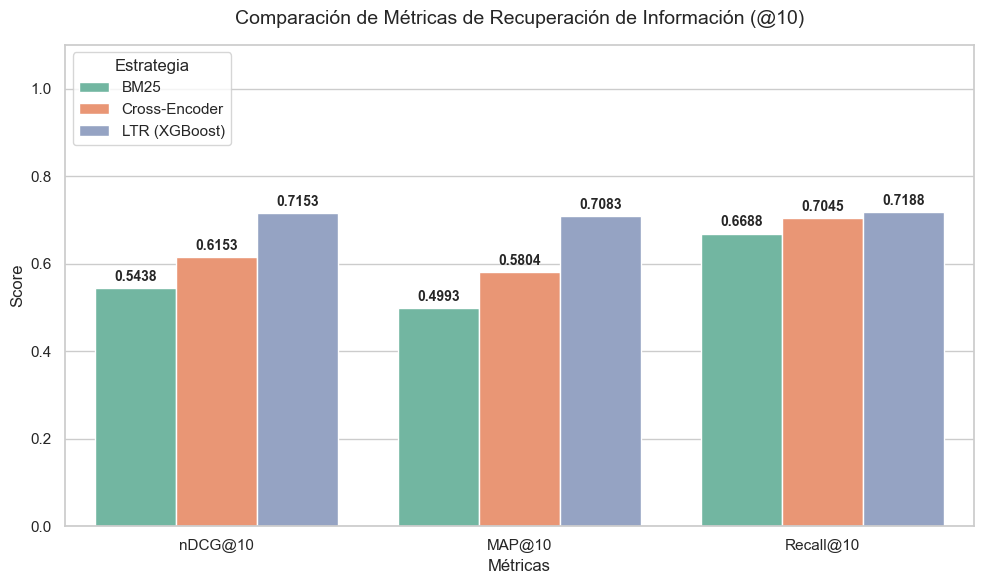


--- Análisis de Ranking para Query 133 ---
Top 5 BM25 docs:          ['26688294', '37964706', '9507605', '5270265', '12785130']
Top 5 Cross-Encoder docs: ['12640810', '6969753', '9507605', '17934082', '86694016']
Top 5 LTR docs:           ['12640810', '17934082', '5270265', '26688294', '86694016']


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Ejecutar las evaluaciones de BEIR
ndcg_bm25, map_bm25, recall_bm25, _ = evaluator.evaluate(qrels, bm25_results, k_values=[10])
ndcg_ce, map_ce, recall_ce, _ = evaluator.evaluate(qrels, ce_results, k_values=[10])
ndcg_ltr, map_ltr, recall_ltr, _ = evaluator.evaluate(qrels, ltr_results, k_values=[10])

# 2. Imprimir los resultados en texto (Consola)
print("\n=== Resultados BASELINE BM25 ===")
print(f"nDCG@10: {ndcg_bm25['NDCG@10']:.4f}")
print(f"MAP@10:  {map_bm25['MAP@10']:.4f}")
print(f"Recall@10: {recall_bm25['Recall@10']:.4f}")

print("\n=== Resultados CROSS-ENCODER ===")
print(f"nDCG@10: {ndcg_ce['NDCG@10']:.4f}")
print(f"MAP@10:  {map_ce['MAP@10']:.4f}")
print(f"Recall@10: {recall_ce['Recall@10']:.4f}")

print("\n=== Resultados LEARNING TO RANK ===")
print(f"nDCG@10: {ndcg_ltr['NDCG@10']:.4f}")
print(f"MAP@10:  {map_ltr['MAP@10']:.4f}")
print(f"Recall@10: {recall_ltr['Recall@10']:.4f}")

# 3. Construir un DataFrame para graficar los resultados de forma limpia
data_metrics = {
    "Modelo": ["BM25", "BM25", "BM25", "Cross-Encoder", "Cross-Encoder", "Cross-Encoder", "LTR (XGBoost)", "LTR (XGBoost)", "LTR (XGBoost)"],
    "Métrica": ["nDCG@10", "MAP@10", "Recall@10", "nDCG@10", "MAP@10", "Recall@10", "nDCG@10", "MAP@10", "Recall@10"],
    "Valor": [
        ndcg_bm25['NDCG@10'], map_bm25['MAP@10'], recall_bm25['Recall@10'],
        ndcg_ce['NDCG@10'], map_ce['MAP@10'], recall_ce['Recall@10'],
        ndcg_ltr['NDCG@10'], map_ltr['MAP@10'], recall_ltr['Recall@10']
    ]
}
df_plot = pd.DataFrame(data_metrics)

# 4. Configurar y generar el gráfico de barras comparativo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Crear el gráfico agrupado por Métrica y coloreado por Modelo
ax = sns.barplot(x="Métrica", y="Valor", hue="Modelo", data=df_plot, palette="Set2")

# Añadir las etiquetas con los valores numéricos encima de cada barra
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.4f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold')

plt.title("Comparación de Métricas de Recuperación de Información (@10)", fontsize=14, pad=15)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Métricas", fontsize=12)
plt.ylim(0, 1.1) # Margen superior para las etiquetas numéricas
plt.legend(title="Estrategia", loc="upper left")
plt.tight_layout()

# Mostrar la gráfica dentro de Jupyter
plt.show()

# 5. Comparativa rápida analítica para la query 133
qid_test = "133"
print(f"\n--- Análisis de Ranking para Query {qid_test} ---")
top_bm25 = list(bm25_results[qid_test].keys())[:5]
top_ce = list(ce_results[qid_test].keys())[:5]
top_ltr = list(ltr_results[qid_test].keys())[:5]

print(f"Top 5 BM25 docs:          {top_bm25}")
print(f"Top 5 Cross-Encoder docs: {top_ce}")
print(f"Top 5 LTR docs:           {top_ltr}")